# kNN-VC — Inference-only

Tier 1 per `docs/resource_estimate.md`: use the released pretrained WavLM encoder and HiFi-GAN vocoder
as-is, no training. Every stage of the pipeline gets its own cell so the math from `docs/maths.md` is
visible on real tensors, instead of calling the library's single `.match()` convenience method as a
black box.

Reference: `docs/notes/knn-vc.md` (paper notes), `docs/maths.md` (math background), `docs/plan.md` (this plan).

Pipeline: **encoder (WavLM layer 6)** &rarr; **kNN matching (hand-rolled here)** &rarr; **vocoder (HiFi-GAN)**.


In [2]:
import torch
import torchaudio
import matplotlib.pyplot as plt
from IPython.display import Audio, display

print(f"torch {torch.__version__}, torchaudio {torchaudio.__version__}")

# knn-vc's own hub loader only checks CUDA (see hubconf.py: wavlm_large falls back to
# cpu if no CUDA, but hifigan_wavlm does not) -- mixing cuda-absent + mps present would
# leave encoder and vocoder on different devices. Stick to cuda -> cpu to avoid that bug.
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"using device: {device}")

torch 2.13.0, torchaudio 2.11.0
using device: cpu


## 1. Load the pretrained pipeline (encoder + vocoder — black boxes for Tier 1)

`prematched=True` loads the HiFi-GAN variant trained on prematched features (Section 3.4 of the paper,
`docs/notes/knn-vc.md` M section) — the better-performing variant per Table 1.


In [3]:
knn_vc = torch.hub.load(
    "bshall/knn-vc", "knn_vc",
    prematched=True, trust_repo=True, pretrained=True, device=device,
)

n_wavlm = sum(p.numel() for p in knn_vc.wavlm.parameters())
n_hifigan = sum(p.numel() for p in knn_vc.hifigan.parameters())
print(f"WavLM-Large encoder:  {n_wavlm:,} params (frozen)")
print(f"HiFi-GAN vocoder:     {n_hifigan:,} params (frozen)")
print(f"sample rate:          {knn_vc.sr} Hz")
print(f"hop length:           {knn_vc.hop_length} samples -> {1000 * knn_vc.hop_length / knn_vc.sr:.0f} ms/frame")


Using cache found in /Users/prashant/.cache/torch/hub/bshall_knn-vc_master
/Users/prashant/Desktop/Projects/paper/knn-vc/.venv/lib/python3.12/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Removing weight norm...
[HiFiGAN] Generator loaded with 16,523,393 parameters.
WavLM-Large loaded with 315,453,120 parameters.
WavLM-Large encoder:  315,453,120 params (frozen)
HiFi-GAN vocoder:     16,523,393 params (frozen)
sample rate:          16000 Hz
hop length:           320 samples -> 20 ms/frame


In [4]:
knn_vc.hifigan

Generator(
  (lin_pre): Linear(in_features=1024, out_features=512, bias=True)
  (conv_pre): Conv1d(512, 512, kernel_size=(7,), stride=(1,), padding=(3,))
  (ups): ModuleList(
    (0): ConvTranspose1d(512, 256, kernel_size=(20,), stride=(10,), padding=(5,))
    (1): ConvTranspose1d(256, 128, kernel_size=(16,), stride=(8,), padding=(4,))
    (2): ConvTranspose1d(128, 64, kernel_size=(4,), stride=(2,), padding=(1,))
    (3): ConvTranspose1d(64, 32, kernel_size=(4,), stride=(2,), padding=(1,))
  )
  (resblocks): ModuleList(
    (0): ResBlock1(
      (convs1): ModuleList(
        (0): Conv1d(256, 256, kernel_size=(3,), stride=(1,), padding=(1,))
        (1): Conv1d(256, 256, kernel_size=(3,), stride=(1,), padding=(3,), dilation=(3,))
        (2): Conv1d(256, 256, kernel_size=(3,), stride=(1,), padding=(5,), dilation=(5,))
      )
      (convs2): ModuleList(
        (0-2): 3 x Conv1d(256, 256, kernel_size=(3,), stride=(1,), padding=(1,))
      )
    )
    (1): ResBlock1(
      (convs1): Modu

## 2. Get audio — LibriSpeech dev-clean

Auto-downloads dev-clean (~337MB, one-time, cached under `./data`). Picks one utterance from a
source speaker (the query / content to convert) and a few utterances from a different speaker
(the reference set / target voice).


In [5]:
from torchaudio.datasets import LIBRISPEECH

dataset = LIBRISPEECH(root="./data", url="dev-clean", download=True)

# get_metadata avoids decoding audio, just reads filenames -- fast way to group by speaker
speaker_to_indices = {}
for i in range(len(dataset)):
    _, _, _, speaker_id, _, _ = dataset.get_metadata(i)
    speaker_to_indices.setdefault(speaker_id, []).append(i)

speakers = sorted(speaker_to_indices)
source_speaker, target_speaker = speakers[0], speakers[1]
print(f"source speaker: {source_speaker} ({len(speaker_to_indices[source_speaker])} utterances)")
print(f"target speaker: {target_speaker} ({len(speaker_to_indices[target_speaker])} utterances)")

source_wave, source_sr, source_text, *_ = dataset[speaker_to_indices[source_speaker][0]]
ref_indices = speaker_to_indices[target_speaker][:5]
ref_waves = [dataset[i][0] for i in ref_indices]

assert source_sr == knn_vc.sr, f"expected {knn_vc.sr}Hz, LibriSpeech gave {source_sr}Hz"
print(f"\nsource text: \"{source_text}\"")
print(f"source duration: {source_wave.shape[-1] / source_sr:.2f}s")
print(f"reference set: {len(ref_waves)} utterances, {sum(w.shape[-1] for w in ref_waves) / source_sr:.1f}s total")


source speaker: 84 (65 utterances)
target speaker: 174 (59 utterances)

source text: "GO DO YOU HEAR"
source duration: 2.09s
reference set: 5 utterances, 51.0s total


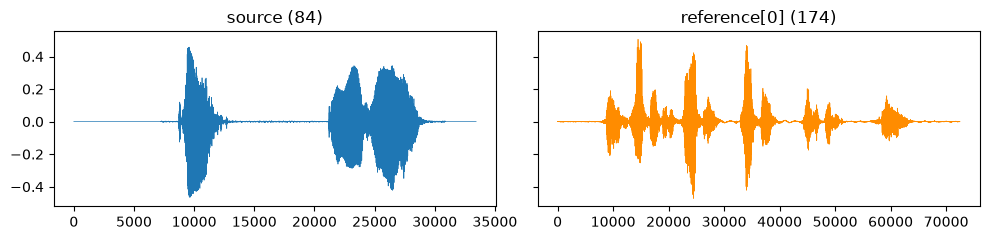

source:


reference[0]:


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 2.5), sharey=True)
axes[0].plot(source_wave[0].numpy(), linewidth=0.5)
axes[0].set_title(f"source ({source_speaker})")
axes[1].plot(ref_waves[0][0].numpy(), linewidth=0.5, color="darkorange")
axes[1].set_title(f"reference[0] ({target_speaker})")
plt.tight_layout()
plt.show()

print("source:")
display(Audio(source_wave.numpy(), rate=source_sr))
print("reference[0]:")
display(Audio(ref_waves[0].numpy(), rate=source_sr))


## 3. Encoder step (`maths.md` &sect;2) — WavLM layer-6 features, per file

`knn_vc.get_features()` runs the frozen WavLM-Large encoder and pulls layer 6 (the
speaker/prosody-correlated layer the paper settled on after ablating other layers).
One 1024-dim vector comes out per 20ms frame.


In [7]:
query_seq = knn_vc.get_features(source_wave)
print(f"query (source) features: {tuple(query_seq.shape)}  "
      f"[expected T ~= {source_wave.shape[-1] / source_sr / 0.02:.0f} frames]")

ref_feats = [knn_vc.get_features(w) for w in ref_waves]
for i, f in enumerate(ref_feats):
    print(f"reference[{i}] features: {tuple(f.shape)}")

query (source) features: (104, 1024)  [expected T ~= 104 frames]
reference[0] features: (226, 1024)
reference[1] features: (232, 1024)
reference[2] features: (792, 1024)
reference[3] features: (658, 1024)
reference[4] features: (638, 1024)


### Visualize: does phonetic content really cluster in feature space?

The paper's whole premise (`maths.md` &sect;1-2) is that WavLM frames of similar phonetic content sit
close together regardless of speaker. 2D PCA projection of source vs. reference frames — same
speaker should NOT form two separable blobs if this premise holds; instead frames should mix
according to phonetic content, not speaker identity.


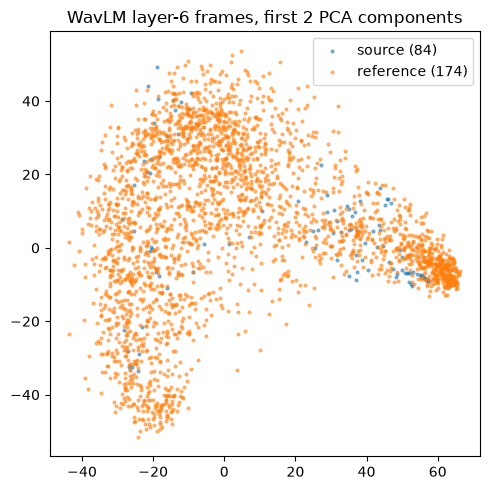

In [17]:
all_feats = torch.cat([query_seq] + ref_feats, dim=0)
_, _, v = torch.pca_lowrank(all_feats, q=2)
proj = all_feats @ v[:, :2]

n_src = query_seq.shape[0]
plt.figure(figsize=(5, 5))
plt.scatter(*proj[:n_src].T, s=4, alpha=0.5, label=f"source ({source_speaker})")
plt.scatter(*proj[n_src:].T, s=4, alpha=0.5, label=f"reference ({target_speaker})")
plt.legend()
plt.title("WavLM layer-6 frames, first 2 PCA components")
plt.tight_layout()
plt.show()


## 4. Matching set (`maths.md` &sect;1)

`get_matching_set` re-extracts features for the reference utterances and concatenates them into one
pool — this is the "bag of vectors" the kNN step searches over. Note it applies front/back
silence trimming by default (`vad_trigger_level=7`), so the frame count can differ slightly from the
sum of the per-file counts above.


In [18]:
matching_set = knn_vc.get_matching_set(ref_waves)
print(f"matching set: {tuple(matching_set.shape)} ({matching_set.shape[0]} frames from "
      f"{len(ref_waves)} reference utterances)")


matching set: (2349, 1024) (2349 frames from 5 reference utterances)


## 5. Manual kNN matching — hand-rolled (`maths.md` &sect;1)

This is the entire "conversion" step, and it has zero learned parameters. Reimplemented here
directly (not calling `knn_vc.match()`) to make the cosine distance and top-k averaging explicit:

- cosine distance: `d(x, y) = 1 - (x&middot;y) / (&Vert;x&Vert; &Vert;y&Vert;)`
- for each query frame, take the mean of its k=4 nearest matching-set frames (uniform weights)

This mirrors `fast_cosine_dist` + `topk` + `mean` in the library's `matcher.py`, just written out
plainly instead of the numerically-optimized `cdist` trick they use.


In [19]:
def cosine_dist(a, b):
    a_norm = a / a.norm(dim=-1, keepdim=True)
    b_norm = b / b.norm(dim=-1, keepdim=True)
    return 1 - a_norm @ b_norm.T

k = 4
dists = cosine_dist(query_seq, matching_set)          # (n_query_frames, n_matching_frames)
best = dists.topk(k, largest=False, dim=-1)            # smallest distance = nearest neighbor
out_feats = matching_set[best.indices].mean(dim=1)     # (n_query_frames, 1024)

print(f"distance matrix: {tuple(dists.shape)}")
print(f"converted features: {tuple(out_feats.shape)}  (same length as query, now averaged from target speaker)")


distance matrix: (104, 2349)
converted features: (104, 1024)  (same length as query, now averaged from target speaker)


### Which reference frames got picked? (unit-selection view)

For a handful of example query frames: their k=4 nearest matching-set frame indices and distances.
This is the concatenative/"unit selection" character of the method made concrete.


query frame    0 -> matching-set frames [186, 0, 1754, 383] (distances ['0.160', '0.165', '0.235', '0.270'])
query frame   52 -> matching-set frames [2182, 2183, 648, 2180] (distances ['0.258', '0.264', '0.268', '0.268'])
query frame  103 -> matching-set frames [185, 382, 2348, 1753] (distances ['0.164', '0.199', '0.207', '0.237'])


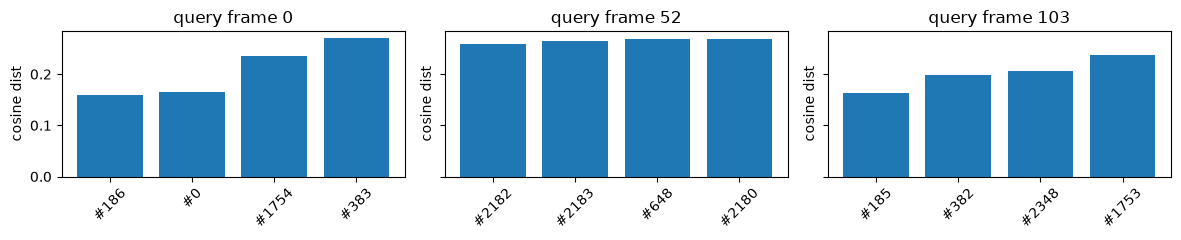

In [20]:
example_frames = [0, query_seq.shape[0] // 2, query_seq.shape[0] - 1]

fig, axes = plt.subplots(1, len(example_frames), figsize=(4 * len(example_frames), 2.5), sharey=True)
for ax, t in zip(axes, example_frames):
    idxs = best.indices[t].tolist()
    ds = best.values[t].tolist()
    ax.bar(range(k), ds)
    ax.set_xticks(range(k))
    ax.set_xticklabels([f"#{i}" for i in idxs], rotation=45)
    ax.set_title(f"query frame {t}")
    ax.set_ylabel("cosine dist")
    print(f"query frame {t:4d} -> matching-set frames {idxs} (distances {[f'{d:.3f}' for d in ds]})")
plt.tight_layout()
plt.show()


## 6. Vocoder step (`maths.md` &sect;3/&sect;4, black box)

Feed the manually-computed `out_feats` into the frozen HiFi-GAN vocoder via `knn_vc.vocode()`
(expects shape `(batch, seq_len, 1024)`). Then compare mel-spectrograms of source, reference, and
converted audio, using the paper's own config (`maths.md` &sect;3): 128 mel bins, 10ms hop, 64ms Hann window.


converted waveform: (33280,) (2.08s)


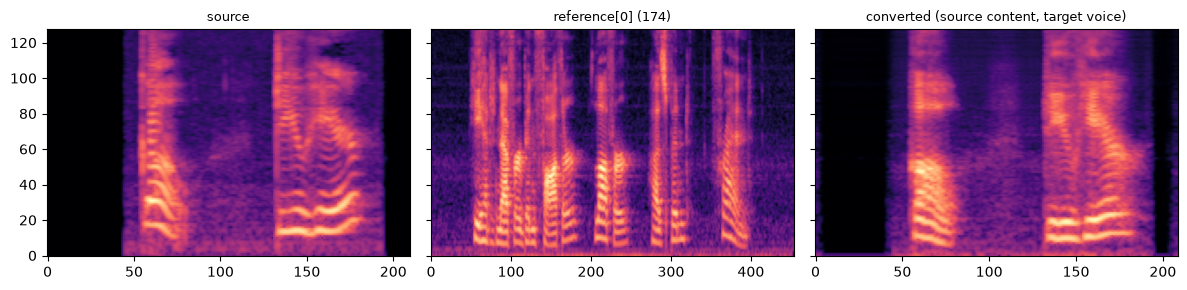

In [22]:
converted_wav = knn_vc.vocode(out_feats[None].to(device)).cpu().squeeze()
print(f"converted waveform: {tuple(converted_wav.shape)} ({converted_wav.shape[-1] / knn_vc.sr:.2f}s)")

mel_fn = torchaudio.transforms.MelSpectrogram(
    sample_rate=knn_vc.sr, n_fft=1024, win_length=1024, hop_length=160, n_mels=128,
)

fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
for ax, wav, title in zip(
    axes,
    [source_wave[0], ref_waves[0][0], converted_wav],
    ["source", f"reference[0] ({target_speaker})", "converted (source content, target voice)"],
):
    log_mel = torch.log(mel_fn(wav) + 1e-6)
    ax.imshow(log_mel.numpy(), origin="lower", aspect="auto", cmap="magma")
    ax.set_title(title, fontsize=9)
plt.tight_layout()
plt.show()


## 7. Listen

In [23]:
print("source (original content + voice):")
display(Audio(source_wave.numpy(), rate=source_sr))
print("reference (target voice):")
display(Audio(ref_waves[0].numpy(), rate=source_sr))
print("converted (source content, target voice):")
display(Audio(converted_wav.numpy(), rate=knn_vc.sr))


source (original content + voice):


reference (target voice):


converted (source content, target voice):


## 8. Correctness check against the official `.match()`

Calls the library's own one-liner (with loudness normalization disabled, since our manual
version above doesn't apply it either) and diffs it against the hand-rolled pipeline. If this
matches, the step-by-step version above is a faithful, non-divergent reimplementation.


In [24]:
official_wav = knn_vc.match(query_seq, matching_set, topk=k, tgt_loudness_db=None).cpu()

max_abs_diff = (converted_wav - official_wav).abs().max().item()
print(f"max abs diff vs knn_vc.match(): {max_abs_diff:.2e}")
assert torch.allclose(converted_wav, official_wav, atol=1e-4), "manual pipeline diverged from the reference implementation"
print("manual step-by-step pipeline matches the official implementation.")


max abs diff vs knn_vc.match(): 0.00e+00
manual step-by-step pipeline matches the official implementation.


## Wrap-up

This notebook covers **Tier 1 only**: pretrained WavLM encoder + pretrained HiFi-GAN vocoder,
hand-rolled kNN matching in between, no training anywhere. What it does *not* cover, per
`docs/resource_estimate.md`:

- **Tier 2** — training the HiFi-GAN vocoder yourself (plain vs. prematched variants), reproducing
  the target-data-size ablation (Figure 2 in the paper).
- **Tier 3** — quantitative benchmark reproduction: WER/CER via ASR, EER via x-vector speaker
  verification, comparison against the VQMIVC/FreeVC/YourTTS baselines, subjective MOS/SIM.

Next step if continuing: Tier 2, starting with LibriSpeech train-clean-100 and the prematching
data construction described in `docs/notes/knn-vc.md` (Method section, "Prematched vocoder
training").
